In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from corner import corner

# check out the data

In [2]:
!ls data-inst-fft

current_foreground_noise_model.dat  foreground_noise_model.dat
current_instrument_noise_model.dat  full_noise_model.dat
current_sgwb_noise_model.dat        instrument_noise_model.dat
dft_data.dat                        power_data.dat
dwt_data.dat                        power_noise_reconstruction.dat
final_foreground_noise_model.dat    scaleogram_data.dat
final_full_noise_model.dat          sgwb_noise_model.dat
final_instrument_noise_model.dat    whitened_data.dat
final_sgwb_noise_model.dat


In [3]:
!ls data-inst-wdm

current_instrument_noise_model.dat  instrument_noise_model.dat
dft_data.dat                        power_data.dat
dwt_data.dat                        power_noise_reconstruction.dat
final_instrument_noise_model.dat    scaleogram_data.dat
full_noise_model.dat                whitened_data.dat


In [4]:
scaleogram_data = np.loadtxt('data-inst-wdm/scaleogram_data.dat')
full_wdm_noise = np.loadtxt('data-inst-wdm/full_noise_model.dat')
dwt_data = np.loadtxt('data-inst-wdm/dwt_data.dat')
wdm_dft_data = np.loadtxt('data-inst-wdm/dft_data.dat')

In [5]:
power_data = np.loadtxt('data-inst-fft/full_noise_model.dat')


In [6]:
power_data[:,1]

array([4.00109e-43, 3.99890e-43, 3.99671e-43, ..., 8.79658e-42,
       8.79818e-42, 8.79978e-42], shape=(19440,))

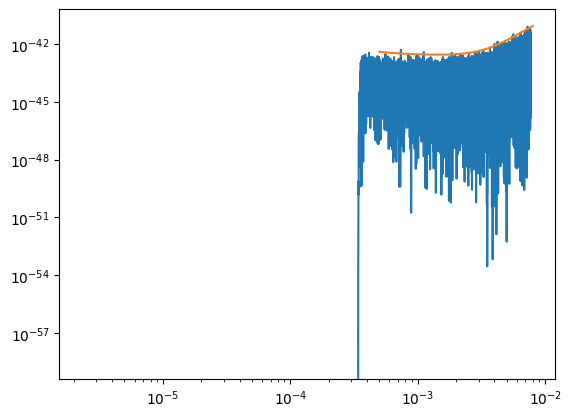

In [7]:
plt.loglog(wdm_dft_data[:,0], np.abs(wdm_dft_data[:,1])**2)
plt.loglog(power_data[:,0], power_data[:,1])

In [701]:
# cols are t, f, |X|^2, |Y|^2, |Z|^2

In [8]:
scaleogram_data.shape

(39766, 5)

In [9]:
# cols are t, f, CXX, CYY, CZZ, CXY, CXZ, CYZ

In [10]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from matplotlib import colors
%matplotlib inline
# TODO: separate real/imag FFT coeffs in each layer
def wavelet_specgram(t, f, pz, Nt = 512, clip = 0, lognorm=False, cmap='bwr', cx_norm='abs'):
    Nf = t.shape[0] // Nt
    if t.shape[0] != Nt*Nf or f.shape[0] != Nt*Nf:
        print("Nt or Nf is wrong")
    z = pz.copy()
    if lognorm:
        z = np.ma.masked_less_equal(z.astype(float), 0)
        lo, hi = np.nanpercentile(z.compressed(), [clip, 100-clip])
        norm = colors.AsinhNorm(vmin=lo, vmax = hi, clip=True)
    else:
        lo, hi = np.nanpercentile(z, [clip, 100-clip])
        norm = colors.Normalize(vmin=lo, vmax = hi, clip=True)
    #plt.imshow(z.reshape((Nf,Nt)),cmap=cmap,norm=norm,aspect=9/16*Nt/Nf,interpolation='none')
    fig, ax = plt.subplots()
    m = ax.pcolormesh(t[::Nf], f[:Nf], z.reshape((Nt,Nf)).T, cmap=cmap, norm=norm, shading='auto',snap=True, rasterized=True)
    fig.colorbar(m,ax=ax)
    plt.xlabel('t')
    plt.ylabel('f')
    plt.show()
    

In [11]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,2], Nt=337)

NameError: name 'full_noise' is not defined

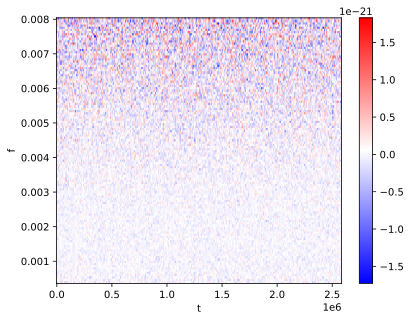

In [12]:
wavelet_specgram(dwt_data[:,0], dwt_data[:,1], dwt_data[:,2], Nt=337)

In [13]:
np.max(counts)

NameError: name 'counts' is not defined

In [14]:
# gaussianity test of generated data
# fudge_factor = 3 # implemented in code
fudge_factor = 0.5
counts,bins,_ = plt.hist(dwt_data[:,4] / np.sqrt(0.5*full_noise[:,4]), density=True, bins=100)
x = np.linspace(bins[0],bins[-1],100)
plt.plot(x, np.exp(-x**2 / 2)*np.max(counts), color='k', linestyle = '--')
plt.yscale('log')

NameError: name 'full_noise' is not defined

In [106]:
  whitened = dwt_data[:,4] / np.sqrt(full_noise[:,4])
  print(f"Whitened variance: {np.var(whitened):.4f}")

Whitened variance: 0.4995


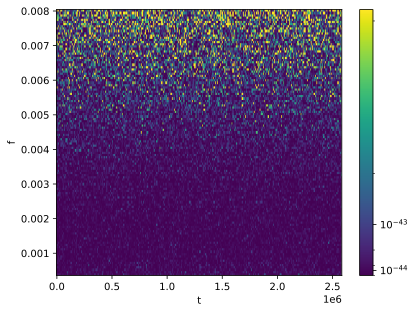

In [107]:
wavelet_specgram(scaleogram_data[:,0], scaleogram_data[:,1], scaleogram_data[:,2], Nt=337, clip=3, lognorm=True, cmap='viridis')

In [108]:
current_inst = np.loadtxt('data/current_instrument_noise_model.dat')
# note that this is frequency-layers only

FileNotFoundError: data/current_instrument_noise_model.dat not found.

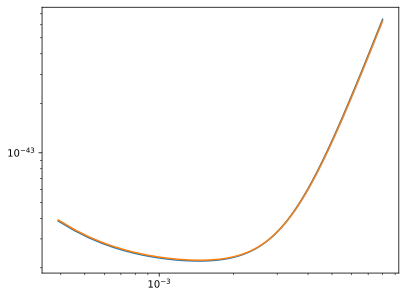

ratio: [1.01500505 1.01457008 1.01420699 1.01390438 1.01364909 1.01342568
 1.01323009 1.01304963 1.01288091 1.01271271 1.01255225 1.01237544
 1.01219458 1.01199755 1.01179319 1.01155757 1.0113115  1.01103432
 1.01073709 1.01040791 1.01004856 1.00966535 1.00924234 1.0087951
 1.00830839 1.00778946 1.00723709 1.00665474 1.00604605 1.00540272
 1.0047334  1.00403882 1.00332393 1.00258254 1.00183135 1.00106112
 1.00028119 0.99949365 0.99870395 0.99790787 0.99711415 0.99632484
 0.99554201 0.9947676  0.99400351 0.99325654 0.99252284 0.99180622
 0.99110548 0.99042391 0.98976637 0.98912695 0.98850827 0.98791425
 0.98733937 0.98678562 0.98625613 0.98574577 0.98525891 0.9847907
 0.98434369 0.98391471 0.98350718 0.9831168  0.98274431 0.98238923
 0.98205204 0.98173005 0.98142665 0.98112915 0.98085201 0.9805865
 0.98033323 0.98009247 0.97985732 0.97964975 0.97944125 0.97923999
 0.97905257 0.9788729  0.97870154 0.97853879 0.97838473 0.97823455
 0.97809377 0.97796236 0.97783594 0.97771043 0.97759499 0.

In [714]:
plt.loglog(current_inst[:,0],current_inst[:,1], label="current noise")
Nf = full_noise.shape[0] // 337
plt.loglog(full_noise[:Nf,1], full_noise[:Nf,2], label="injection")
plt.show()
print(f"ratio: {full_noise[:Nf,2] / current_inst[:,1]}")

# wdm normalization checks

In [17]:
import numpy as np

In [26]:
fftwdmdata = np.loadtxt("./debug_fftwdm_noise.dat")
fftdata = np.loadtxt("./debug_fft_noise.dat")
fftpsd = np.loadtxt("./debug_fft_psd.dat")
wdmdata = np.loadtxt("./debug_wdm_noise.dat")
wdmpsd = np.loadtxt("./debug_wdm_C00.dat")

In [27]:
fftdata.shape

(258817, 3)

In [28]:
wdmdata.shape

(517632, 3)

In [29]:
fftwdmdata.shape

(517632, 3)

In [30]:
fftpsd

array([[0.00000e+00, 0.00000e+00],
       [7.72750e-07, 7.64262e-38],
       [1.54550e-06, 1.91066e-38],
       ...,
       [1.99998e-01, 1.67972e-39],
       [1.99999e-01, 1.67970e-39],
       [2.00000e-01, 1.67967e-39]], shape=(258817, 2))

In [31]:
fftdata[:,2]

array([0.00000e+00, 8.46302e-20, 1.14367e-19, ..., 2.76762e-20,
       1.00914e-20, 1.56886e-20], shape=(258817,))

In [32]:
fftwdmdata[:,2]

array([-7.28304e-23, -6.62600e-23, -7.98472e-23, ...,  3.63932e-25,
       -9.77148e-25, -2.24913e-25], shape=(517632,))

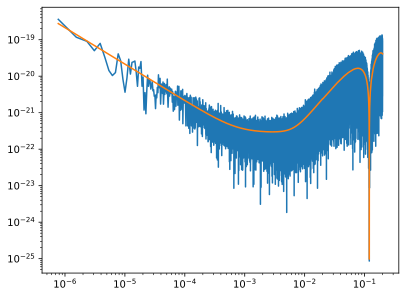

In [33]:
fmin = fftpsd[1,0]
fmax = fftpsd[-1,0]
emin = np.argmin(np.abs(fftdata[:,0] - fmin))
emax = np.argmin(np.abs(fftdata[:,0] - fmax))
plt.loglog(fftdata[emin:emax,0], np.abs(fftdata[emin:emax,1] + 1j*fftdata[emin:emax,2]))
plt.loglog(fftpsd[emin:emax,0], np.sqrt(fftpsd[emin:emax,1]))

In [34]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
from matplotlib import colors
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
#import seaborn as sns

def wavelet_specgram(t, f, pz, fmin = 0, fmax = np.inf, tmin=0, tmax= np.inf, cmap = 'bwr', colorbar=True, vmin=None,vmax=None,log=False,filename=None, logf=False):
    Nt = len(t)
    Nf = len(f)
    if tmax < np.inf:
        et = np.argmin(np.abs(t-tmax))
    else:
        et = Nt-1
    if fmax < np.inf:
        e = np.argmin(np.abs(f-fmax))
    else:
        e = Nf-1
    emin = np.argmin(np.abs(f-fmin))
    etmin = np.argmin(np.abs(t-tmin))
    if pz.size != (Nt-1)*(Nf-1):
        print(pz.shape,Nt,Nf)
        print("Nt or Nf is wrong")
    z = pz[emin:e,etmin:et].copy()
    z /= z.max()
    
    if vmin == None:
        vmin=z.min()+1e-20
    if vmax == None:
        vmax=z.max()
    if log:
        norm = colors.LogNorm(vmin = vmin, vmax=vmax)
    else:
        norm = colors.Normalize(vmin = vmin, vmax = vmax)

    z_clean = np.nan_to_num(z, nan=z.min(), posinf=z.min(), neginf=z.min())

    maxarr=[]
    fig, ax = plt.subplots(figsize=(10,7))
    #plt.pcolormesh(t, f[:e+1], z_clean.reshape((Nt-1,e)).T,cmap=cmap,norm=norm,shading='auto',snap=False, rasterized=True)
    plt.pcolormesh(t[etmin:et+1], f[emin:e+1], z_clean.reshape((e-emin,et-etmin)),cmap=cmap,norm=norm,shading='auto',snap=False, rasterized=True)
    #plt.contourf(t, f[:e+1], z_clean.reshape((e,Nt-1)), levels=100, cmap=cmap,norm=norm,shading='auto',snap=False, rasterized=True)
    plt.grid(False)
    plt.xlabel('t (sec)')
    plt.ylabel('f (Hz)')
    if colorbar:
        plt.colorbar()
    if logf:
        ax.set_yscale('log')
    if filename:
        plt.savefig(filename)
    plt.show()
    return np.real(t[etmin:et+1]), np.real(f[emin:e+1]), z_clean.reshape((e-emin,et-etmin))

def scalogram(data,dt,Nt=128//1,Nf=None, colormap = 'bwr', colorbar=True, vmin=None,log=False,logf = False, filename=None,fmin = 0, fmax=np.inf, tmin=0, tmax = np.inf, whiten_PSD=None, whiten_f = None, overlay_data = None):
    if not Nf:
        Nf = data.shape[0]//Nt
    ND = Nf*Nt
    Tobs = ND*dt
    wt = np.linspace(0,Tobs,Nt+1)
    wf = np.arange(0,Nf+1)*1/(2*dt*Nf)
    dataf = np.fft.fft(data[:ND]*windows.tukey(ND,0.01))
    aa = transform_wavelet_freq(dataf,Nf,Nt).T
    #complex_coeff = aa[:, ::2] + 1j * aa[:, 1::2]
    wt=wt[::2]
    aa = np.abs(aa[:,::2])
    #aa = np.sqrt(aa[:,1::2]**2+aa[:,::2]**2)
    #bb = np.zeros_like(aa)
    #if overlay_data is not None:
    #    overlay_dataf = np.fft.fft(overlay_data[:ND]*windows.tukey(ND,0.01))
    #    cc = transform_wavelet_freq(dataf,Nf,Nt).T
    #    bb = np.abs(cc[:,::2])
    if whiten_f is not None:
        interp_whiten_PSD = np.interp(wf[1:], whiten_f, whiten_PSD)
        aa /= np.sqrt(interp_whiten_PSD[:,np.newaxis])
    #    bb /= np.sqrt(interp_whiten_PSD[:,np.newaxis])
    arr = wavelet_specgram(wt, wf, aa,fmin=fmin, fmax=fmax, tmin=tmin, tmax=tmax, vmin=vmin,log=log,logf=logf,filename=filename, cmap = colormap)#, overlay=(overlay_data is not None), overlay_wPSD = bb)
    return arr

In [41]:
wdmpsd.shape

(517632, 3)

In [48]:
Nf = 1536
Nt = 337
pdata = fftwdmdata
t = pdata[::Nf,0]
f = pdata[:Nf,1]
pz = pdata[:,2].reshape(Nf,Nt)
f = f[1]*np.arange(f.shape[0] + 1)
t = t[1]*np.arange(t.shape[0] + 1)

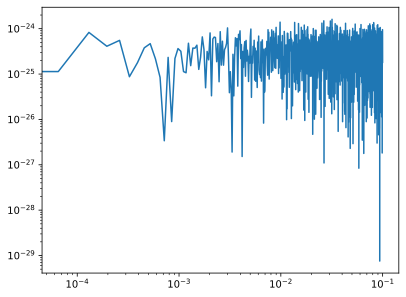

In [54]:
layer = 30
f = wdmpsd[:Nf,1]
plt.loglog(f, np.abs(fftwdmdata[Nf*layer:(layer+1)*Nf,2]))

In [57]:
np.argmax(np.abs(pz))

np.int64(369899)

(1536, 337) 338 1536
Nt or Nf is wrong


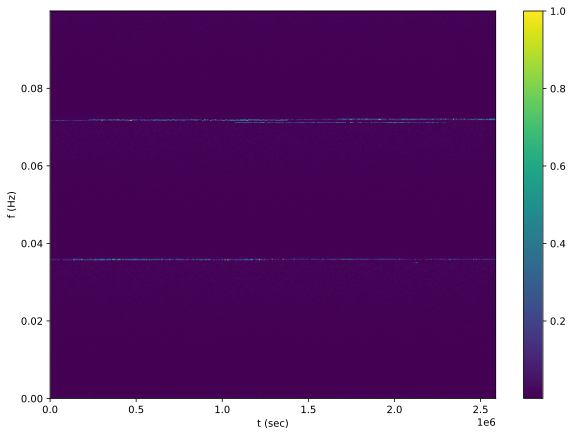

(array([      0.,    7680.,   15360.,   23040.,   30720.,   38400.,
          46080.,   53760.,   61440.,   69120.,   76800.,   84480.,
          92160.,   99840.,  107520.,  115200.,  122880.,  130560.,
         138240.,  145920.,  153600.,  161280.,  168960.,  176640.,
         184320.,  192000.,  199680.,  207360.,  215040.,  222720.,
         230400.,  238080.,  245760.,  253440.,  261120.,  268800.,
         276480.,  284160.,  291840.,  299520.,  307200.,  314880.,
         322560.,  330240.,  337920.,  345600.,  353280.,  360960.,
         368640.,  376320.,  384000.,  391680.,  399360.,  407040.,
         414720.,  422400.,  430080.,  437760.,  445440.,  453120.,
         460800.,  468480.,  476160.,  483840.,  491520.,  499200.,
         506880.,  514560.,  522240.,  529920.,  537600.,  545280.,
         552960.,  560640.,  568320.,  576000.,  583680.,  591360.,
         599040.,  606720.,  614400.,  622080.,  629760.,  637440.,
         645120.,  652800.,  660480.,  668160., 

In [56]:
wavelet_specgram(t, f, np.abs(pz),
                 fmin = 0,
                 fmax = np.inf,
                 tmin=0,
                 tmax= np.inf,
                 cmap = 'viridis',
                 colorbar=True,
                 vmin=None,
                 vmax=None,
                 log=False,
                 filename=None,
                 logf=False)


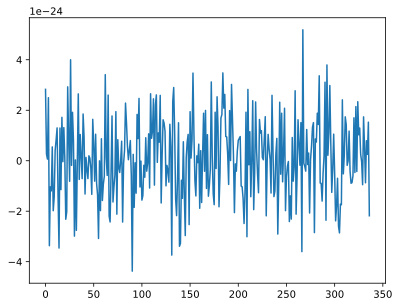

In [116]:
plt.plot(pz[100,:])

# check out the chains

In [67]:
N = 10000
#inst = np.loadtxt('chains-inst-wdm/chains/noise_chain.dat', max_rows=N)
#instf = np.loadtxt('chains-inst-fft/noise_chain.dat', max_rows=N)
inst = np.loadtxt('chains/noise_chain.dat', max_rows=N)

In [59]:
# check if there's a bias from current point to injection

In [60]:
instf.shape

NameError: name 'instf' is not defined

In [61]:
inst.shape

(10000, 14)

In [62]:
plt.plot(instf[:,1])

NameError: name 'instf' is not defined

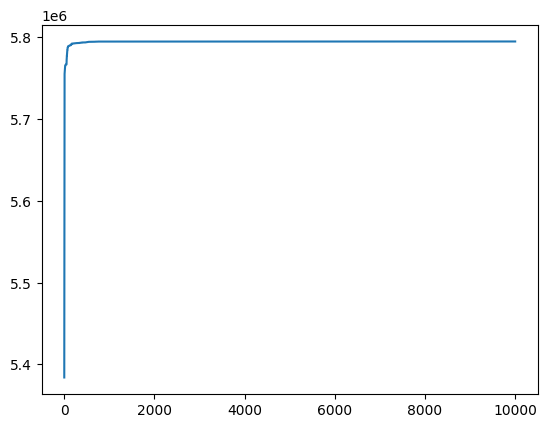

In [69]:
plt.plot(inst[:,1])

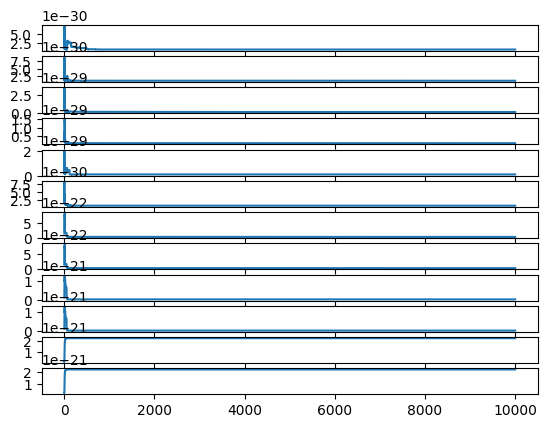

In [68]:
# inst trace
burn = 0
fig, ax = plt.subplots(12,1)
for i in range(12):
    ax[i].plot(inst[burn:,i+2])

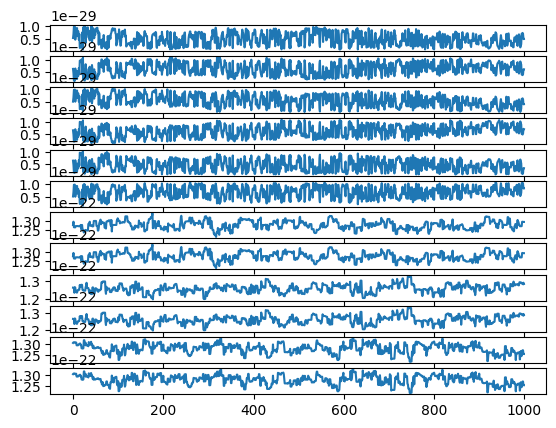

In [11]:
burn = 0
fig, ax = plt.subplots(12,1)
for i in range(12):
    ax[i].plot(instf[burn:,i+2])

In [12]:
from corner import corner

In [65]:
burn = 0
inst_chain = np.array(
    [
        inst[burn:,i+2]
        for i in range(12)
    ]).T
#instf_chain = np.array(
#    [
#        instf[burn:,i+2]
#        for i in range(12)
#    ]).T
inst_labels = [r'$\log S_{\mathrm{acc},12}$',
r'$\log S_{\mathrm{acc},21}$',
r'$\log S_{\mathrm{acc},13}$',
r'$\log S_{\mathrm{acc},31}$',
r'$\log S_{\mathrm{acc},23}$', 
r'$\log S_{\mathrm{acc},32}$', 
r'$\log S_{\mathrm{oms},12}$', 
r'$\log S_{\mathrm{oms},21}$', 
r'$\log S_{\mathrm{oms},13}$', 
r'$\log S_{\mathrm{oms},31}$', 
r'$\log S_{\mathrm{oms},23}$', 
r'$\log S_{\mathrm{oms},32}$']

ValueError: It looks like the parameter(s) in column(s) 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11 have no dynamic range. Please provide a `range` argument.

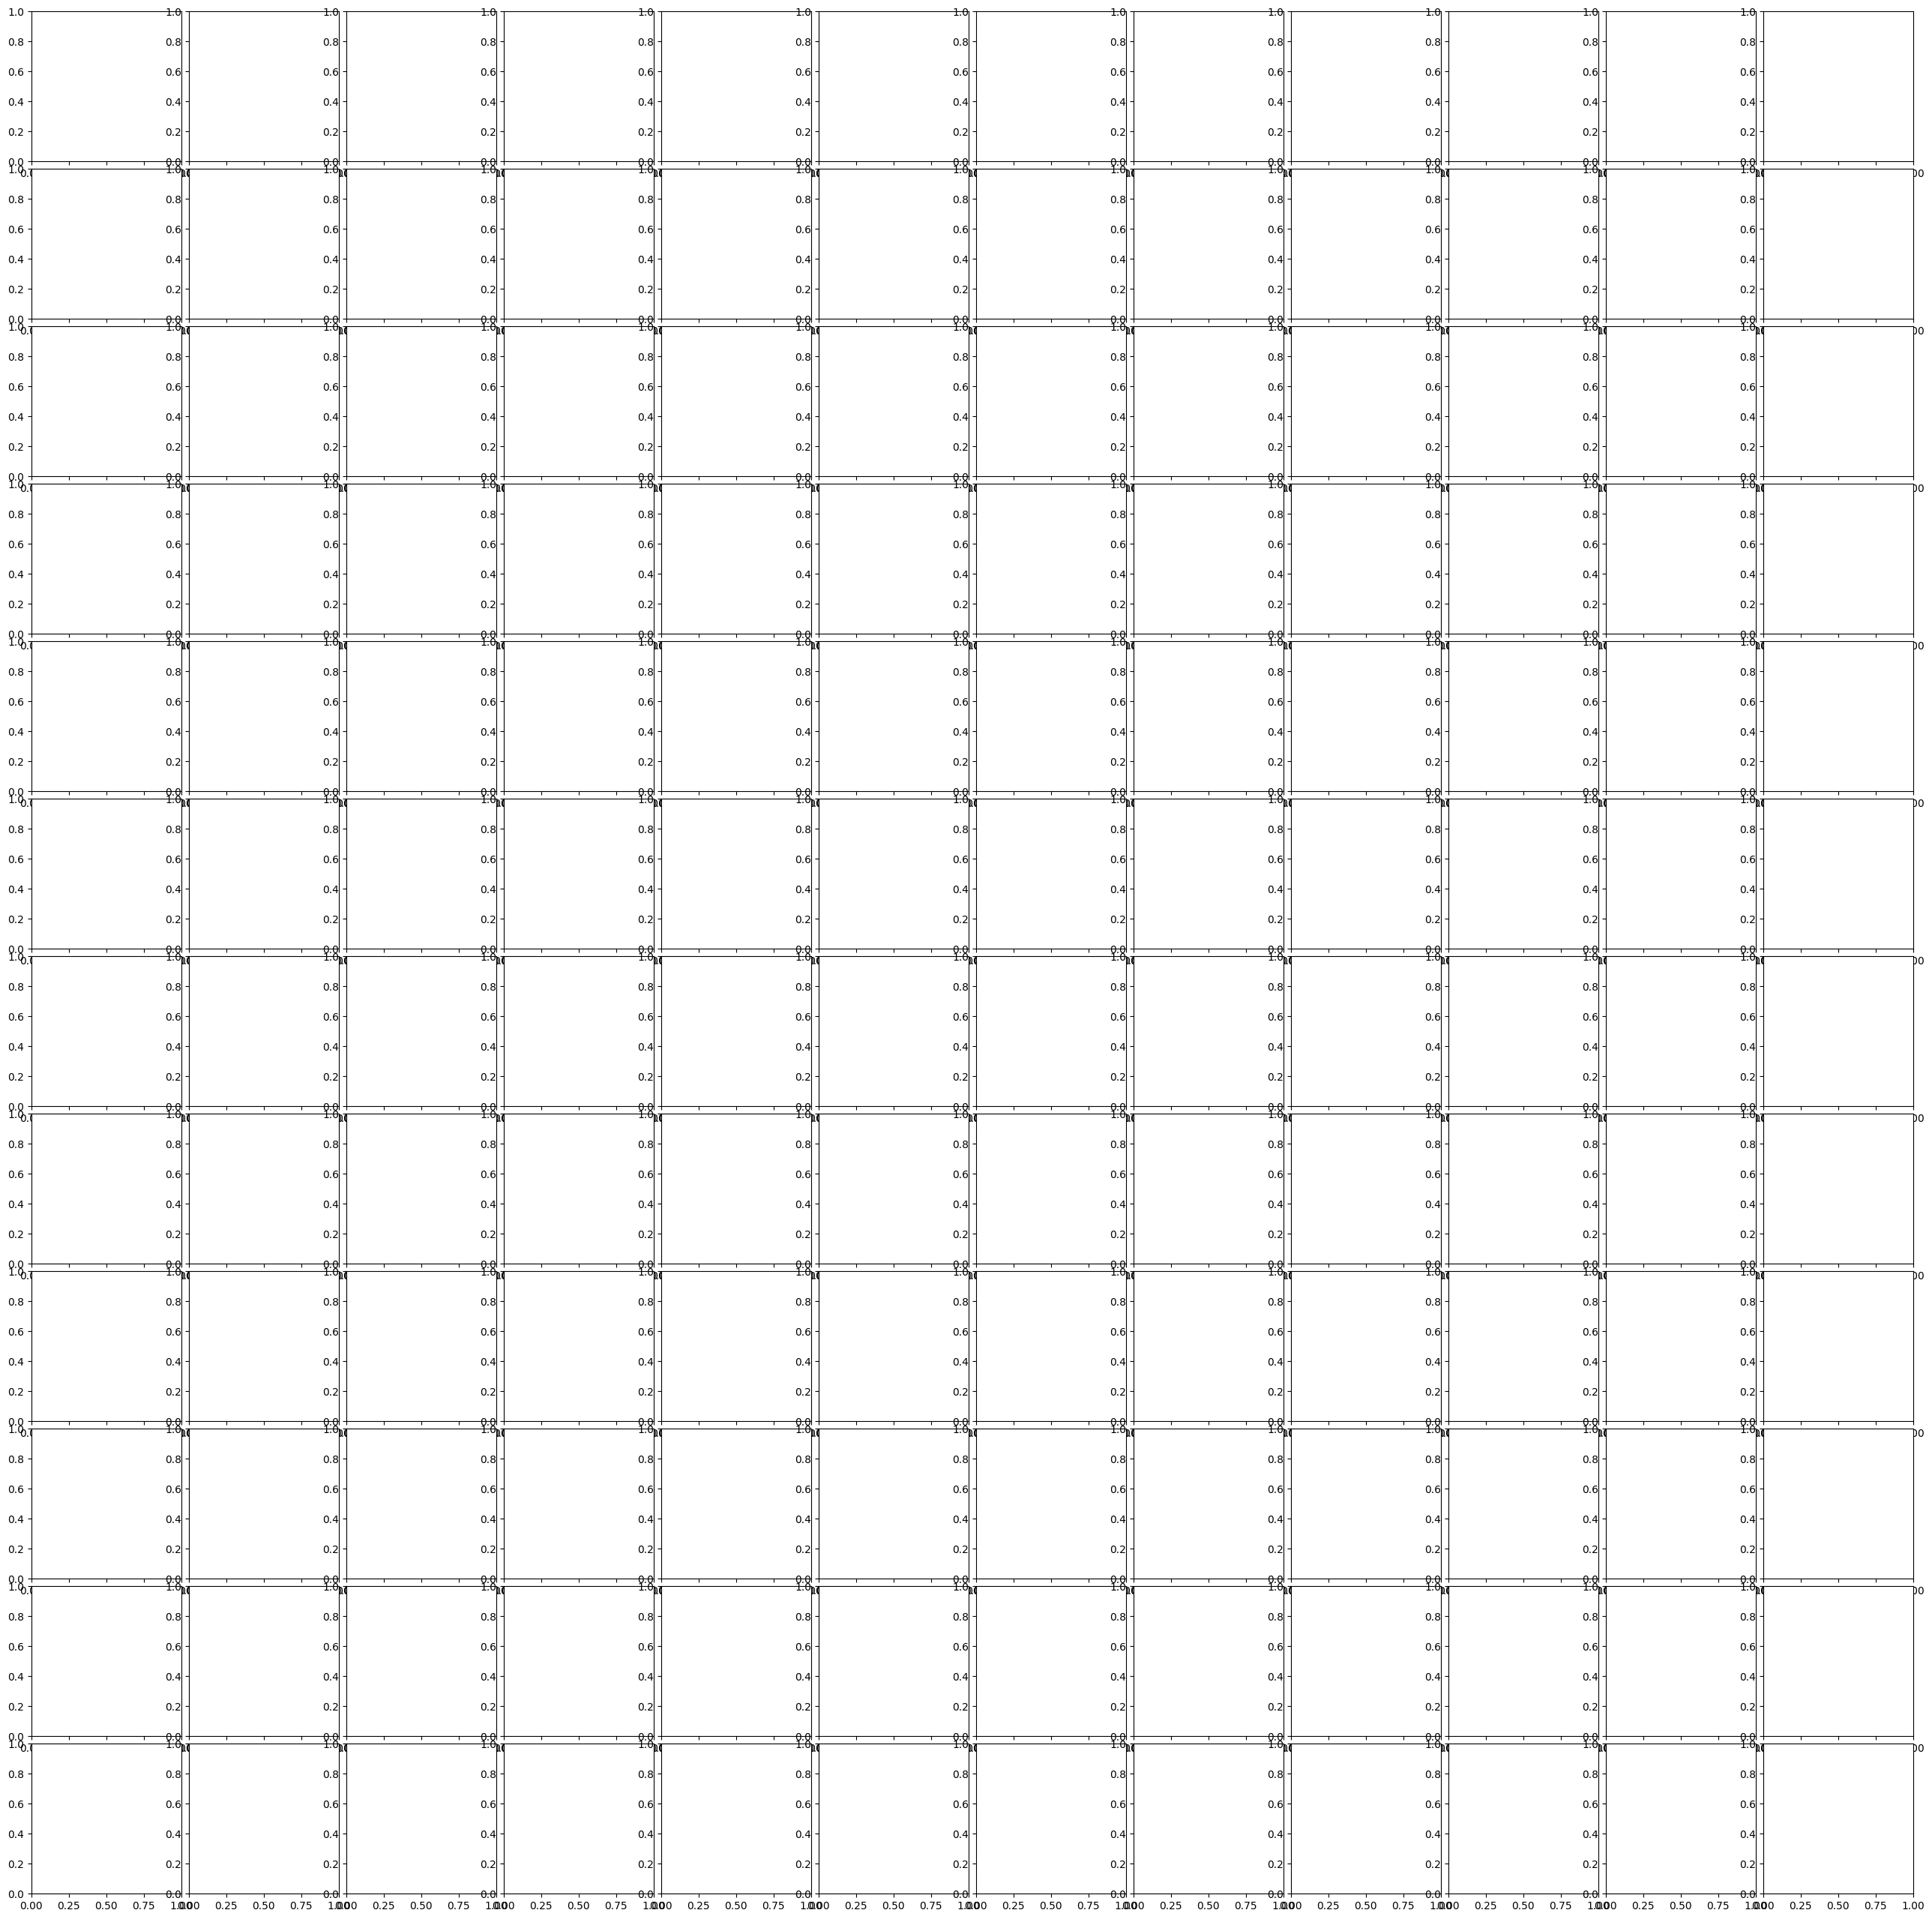

In [66]:
truths = inst[0,2:]
fig = corner(inst_chain, labels = inst_labels, truths = truths, truth_color='red')
#corner(instf_chain, labels = inst_labels, fig=fig, color='blue')
#plt.savefig("fft_wdm_joint_corner.png")
plt.show()

In [14]:
instf[-1,2:]

array([6.01905458e-30, 5.67636670e-30, 6.55382047e-30, 4.64023066e-30,
       3.89006330e-30, 7.18310336e-30, 1.25913493e-22, 1.25913493e-22,
       1.30030451e-22, 1.30030451e-22, 1.32795896e-22, 1.32795896e-22])

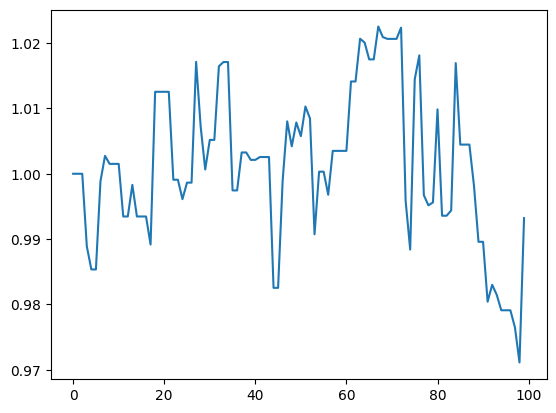

In [15]:
plt.plot([np.median(instf[i,2:] / instf[0,2:]) for i in range(100)]) 

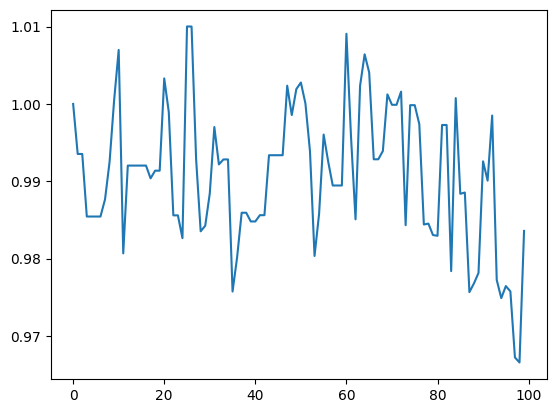

In [16]:
plt.plot([np.median(inst[i,2:] / inst[0,2:]) for i in range(100)]) 

In [17]:
instf[0,2:]

array([2.52224141e-30, 8.94254826e-30, 2.56914775e-30, 8.99775859e-30,
       9.14935017e-30, 2.52819980e-30, 1.28524364e-22, 1.28524364e-22,
       1.30064143e-22, 1.30064143e-22, 1.27769024e-22, 1.27769024e-22])

In [18]:
instf[0,2:] / inst[0,2:]

array([1.        , 1.        , 1.02720828, 1.        , 1.        ,
       1.        , 1.        , 1.        , 0.99198814, 0.99198814,
       1.        , 1.        ])

# fft / wdm python testing

In [60]:
import numpy as np

In [125]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
from matplotlib import colors
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
#import seaborn as sns

def wavelet_specgram(t, f, pz, fmin = 0, fmax = np.inf, tmin=0, tmax= np.inf, cmap = 'bwr', colorbar=True, vmin=None,vmax=None,log=False,filename=None, logf=False):
    Nt = len(t)
    Nf = len(f)
    if tmax < np.inf:
        et = np.argmin(np.abs(t-tmax))
    else:
        et = Nt-1
    if fmax < np.inf:
        e = np.argmin(np.abs(f-fmax))
    else:
        e = Nf-1
    emin = np.argmin(np.abs(f-fmin))
    etmin = np.argmin(np.abs(t-tmin))
    if pz.size != Nt*Nf:
        print(pz.shape,Nt,Nf)
        print("Nt or Nf is wrong")
    z = pz[emin:e,etmin:et].copy()
    #z /= z.max()
    
    if vmin == None:
        vmin=z.min()+1e-60
    if vmax == None:
        vmax=z.max()
    if log:
        norm = colors.LogNorm(vmin = vmin, vmax=vmax)
    else:
        norm = colors.Normalize(vmin = vmin, vmax = vmax)

    z_clean = np.nan_to_num(z, nan=z.min(), posinf=z.min(), neginf=z.min())

    maxarr=[]
    fig, ax = plt.subplots(figsize=(10,7))
    #plt.pcolormesh(t, f[:e+1], z_clean.reshape((Nt-1,e)).T,cmap=cmap,norm=norm,shading='auto',snap=False, rasterized=True)
    plt.pcolormesh(t[etmin:et+1], f[emin:e+1], z_clean.reshape((e-emin,et-etmin)),cmap=cmap,norm=norm,shading='auto',snap=False, rasterized=True)
    #plt.contourf(t, f[:e+1], z_clean.reshape((e,Nt-1)), levels=100, cmap=cmap,norm=norm,shading='auto',snap=False, rasterized=True)
    plt.grid(False)
    plt.xlabel('t (sec)')
    plt.ylabel('f (Hz)')
    if colorbar:
        plt.colorbar()
    if logf:
        ax.set_yscale('log')
    if filename:
        plt.savefig(filename)
    plt.show()
    return np.real(t[etmin:et+1]), np.real(f[emin:e+1]), z_clean.reshape((e-emin,et-etmin))

def scalogram(data,dt,Nt=128//1,Nf=None, colormap = 'bwr', colorbar=True, vmin=None,log=False,logf = False, filename=None,fmin = 0, fmax=np.inf, tmin=0, tmax = np.inf, whiten_PSD=None, whiten_f = None, overlay_data = None):
    if not Nf:
        Nf = data.shape[0]//Nt
    ND = Nf*Nt
    Tobs = ND*dt
    wt = np.linspace(0,Tobs,Nt+1)
    wf = np.arange(0,Nf+1)*1/(2*dt*Nf)
    dataf = np.fft.fft(data[:ND]*windows.tukey(ND,0.01))
    aa = transform_wavelet_freq(dataf,Nf,Nt).T
    #complex_coeff = aa[:, ::2] + 1j * aa[:, 1::2]
    wt=wt[::2]
    aa = np.abs(aa[:,::2])
    #aa = np.sqrt(aa[:,1::2]**2+aa[:,::2]**2)
    #bb = np.zeros_like(aa)
    #if overlay_data is not None:
    #    overlay_dataf = np.fft.fft(overlay_data[:ND]*windows.tukey(ND,0.01))
    #    cc = transform_wavelet_freq(dataf,Nf,Nt).T
    #    bb = np.abs(cc[:,::2])
    if whiten_f is not None:
        interp_whiten_PSD = np.interp(wf[1:], whiten_f, whiten_PSD)
        aa /= np.sqrt(interp_whiten_PSD[:,np.newaxis])
    #    bb /= np.sqrt(interp_whiten_PSD[:,np.newaxis])
    arr = wavelet_specgram(wt, wf, aa,fmin=fmin, fmax=fmax, tmin=tmin, tmax=tmax, vmin=vmin,log=log,logf=logf,filename=filename, cmap = colormap)#, overlay=(overlay_data is not None), overlay_wPSD = bb)
    return arr

In [272]:
WAVELET_DURATION = 7680
NF = 1536
NT = 338
ND = NT*NF
NFFT = ND/2 + 1
Tobs = NT*WAVELET_DURATION

testf = np.arange(NFFT) * 1/Tobs

def randc(psd):
    return np.sqrt(psd/2)*(np.random.randn(*psd.shape) + 1j*np.random.randn(*psd.shape))

def testpsdfunc(x):
    fref = 1e-3
    c = 1e-30
    return c*(x/fref)**2

testpsd = testpsdfunc(testf)
testfft = randc(testpsd)


timeseries = np.fft.irfft(testfft)

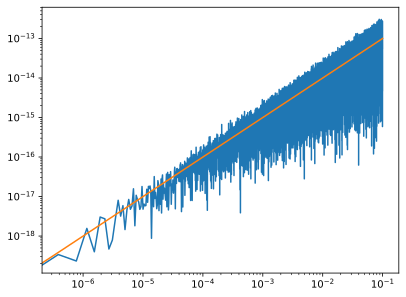

In [273]:
plt.loglog(testf, np.abs(testfft))
plt.loglog(testf, np.sqrt(testpsd))
plt.show()

In [274]:
from WDMWaveletTransforms.wavelet_transforms import (
    transform_wavelet_freq,
    transform_wavelet_freq_time,
    transform_wavelet_time,
)

In [275]:
testwdm = transform_wavelet_freq(testfft, NF, NT)

In [276]:
dt = WAVELET_DURATION / NF

In [277]:
t = np.arange(testwdm.shape[0]) * WAVELET_DURATION
f = np.arange(testwdm.shape[1]) * 1/(2*dt*NF)

In [278]:
testwdm.shape

(338, 1536)

In [279]:
def testpsdfunc(x):
    fref = 1e-3
    c = 1e-30
    return c*(x/fref)**2

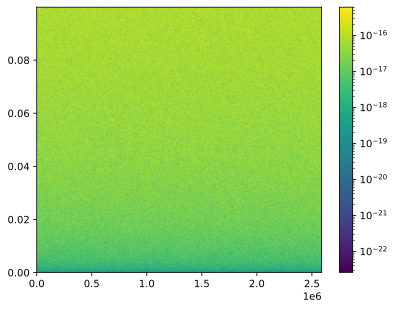

In [280]:
plt.imshow(np.abs(testwdm.T), aspect='auto', origin='lower',extent=(t[0],t[-1],f[0],f[-1]), norm='log')
plt.colorbar()
plt.show()

In [281]:
testwdmpsd = np.repeat([testpsdfunc(f)], NT, axis=0)

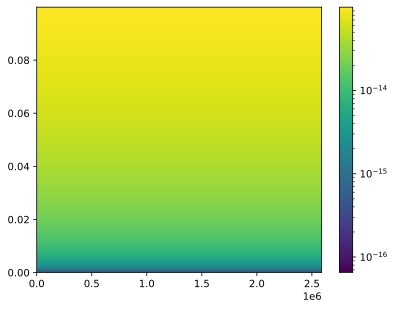

In [282]:
plt.imshow(np.sqrt(testwdmpsd.T), aspect='auto', origin='lower',extent=(t[0],t[-1],f[0],f[-1]), norm='log')
plt.colorbar()
plt.show()

/var/folders/h6/rzz7tfhd0v76qyg_gtclph4c0000gp/T/ipykernel_26329/538367212.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(testwdm.T / np.sqrt(testwdmpsd.T) * np.sqrt(NF*NT), aspect='auto', origin='lower',extent=(t[0],t[-1],f[0],f[-1]))


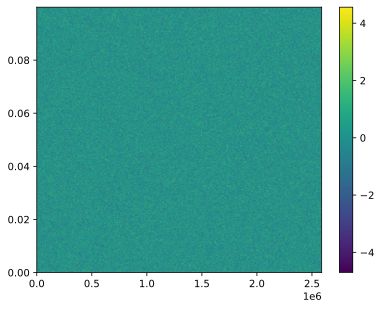

In [293]:
plt.imshow(testwdm.T / np.sqrt(testwdmpsd.T) * np.sqrt(NF*NT), aspect='auto', origin='lower',extent=(t[0],t[-1],f[0],f[-1]))
plt.colorbar()
plt.show()

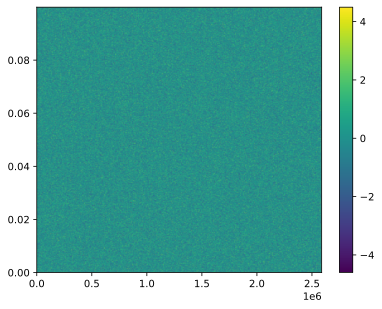

In [284]:
plt.imshow(np.random.randn(NF,NT), aspect='auto', origin='lower',extent=(t[0],t[-1],f[0],f[-1]))
plt.colorbar()
plt.show()

In [285]:
np.std(testwdm.T / np.sqrt(testwdmpsd.T) * np.sqrt(NF*NT), where = ~np.isnan(testwdm.T) & (testwdmpsd.T > 0))

/var/folders/h6/rzz7tfhd0v76qyg_gtclph4c0000gp/T/ipykernel_26329/395474157.py:1: RuntimeWarning: divide by zero encountered in divide
  np.std(testwdm.T / np.sqrt(testwdmpsd.T) * np.sqrt(NF*NT), where = ~np.isnan(testwdm.T) & (testwdmpsd.T > 0))


np.float64(1.0006531341024163)

In [289]:
np.std(np.random.randn(NF,NT))

np.float64(0.9995590570147561)

In [290]:
dt

5.0

In [292]:
(NF, NT, WAVELET_DURATION, dt, f[1], np.sqrt(NF*NT), NF/2)

(1536,
 338,
 7680,
 5.0,
 np.float64(6.510416666666667e-05),
 np.float64(720.5331359486529),
 768.0)